In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

df = pd.read_csv('../data/application_train.csv')
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 325.2 MB


In [7]:
print(df['TARGET'].value_counts())
print()
print(df['TARGET'].value_counts(normalize=True).mul(100).round(2))

TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False).head(20)

,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


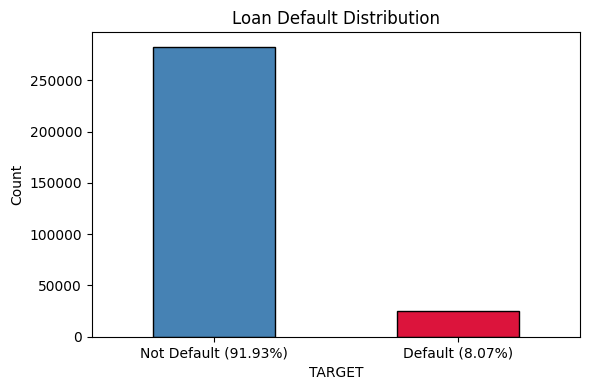

In [9]:
plt.figure(figsize=(6,4))
df['TARGET'].value_counts().plot(kind='bar', 
    color=['steelblue','crimson'], edgecolor='black')
plt.title('Loan Default Distribution')
plt.xticks([0,1], ['Not Default (91.93%)', 'Default (8.07%)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

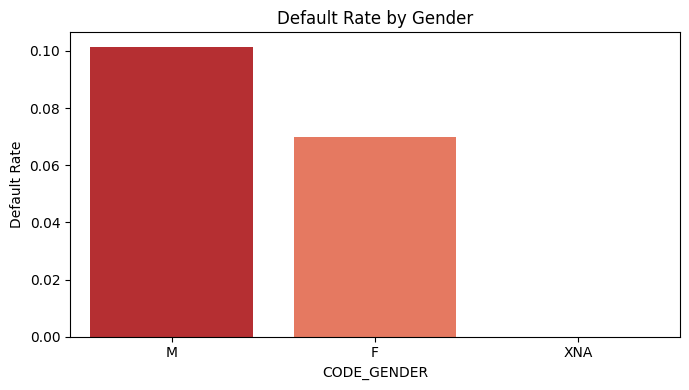

In [10]:
plt.figure(figsize=(7,4))
gender_default = df.groupby('CODE_GENDER')['TARGET'].mean().sort_values(ascending=False)
sns.barplot(x=gender_default.index, y=gender_default.values, palette='Reds_r')
plt.title('Default Rate by Gender')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

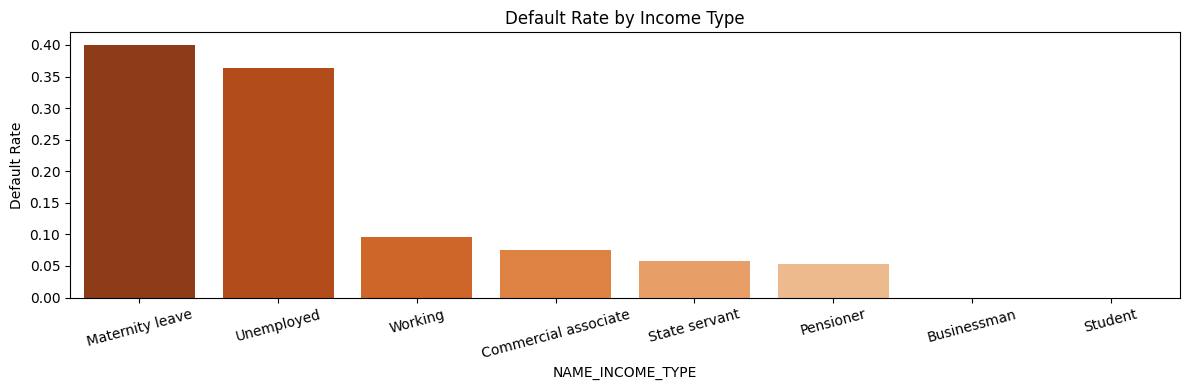

In [11]:
plt.figure(figsize=(12,4))
income_default = df.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values(ascending=False)
sns.barplot(x=income_default.index, y=income_default.values, palette='Oranges_r')
plt.title('Default Rate by Income Type')
plt.ylabel('Default Rate')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

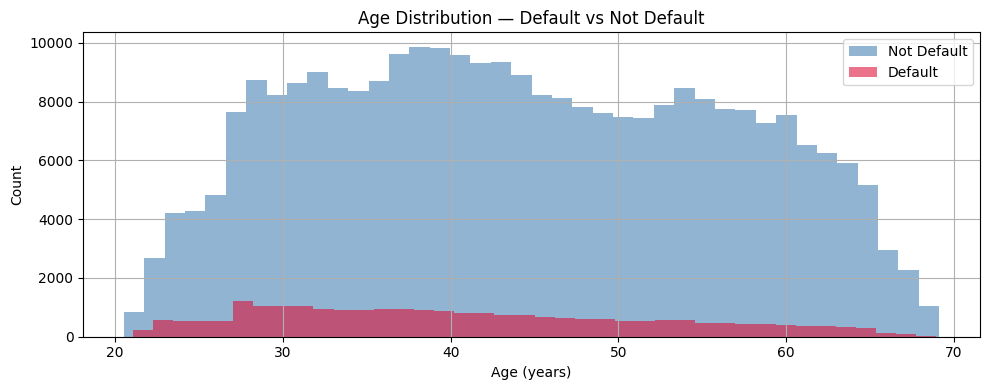

In [12]:
df['AGE_YEARS'] = df['DAYS_BIRTH'] / -365

plt.figure(figsize=(10,4))
df[df['TARGET']==0]['AGE_YEARS'].hist(bins=40, alpha=0.6, label='Not Default', color='steelblue')
df[df['TARGET']==1]['AGE_YEARS'].hist(bins=40, alpha=0.6, label='Default', color='crimson')
plt.legend()
plt.title('Age Distribution — Default vs Not Default')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

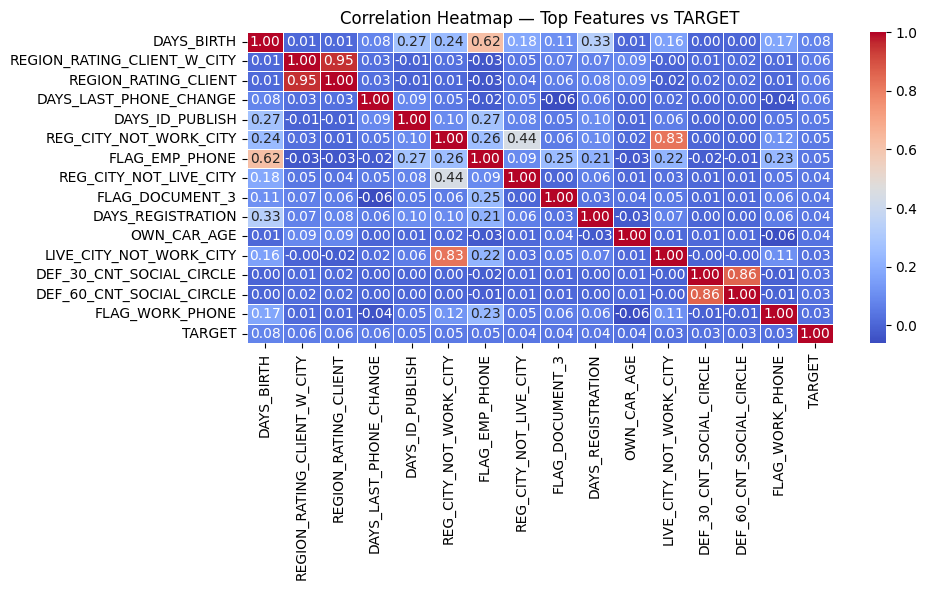

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

correlations = df[numeric_cols].corr()['TARGET'].sort_values(ascending=False)
top_features = correlations[1:16].index.tolist()  

plt.figure(figsize=(10,6))
sns.heatmap(df[top_features + ['TARGET']].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Top Features vs TARGET')
plt.tight_layout()
plt.show()